In [ ]:
import pandas as pd


In [ ]:
df_e = pd.read_csv("DAYTON_hourly.csv")
print(df_e.shape)
display(df_e.head())

(121275, 2)


,Datetime,DAYTON_MW
0,2004-12-31 01:00:00,1596.0
1,2004-12-31 02:00:00,1517.0
2,2004-12-31 03:00:00,1486.0
3,2004-12-31 04:00:00,1469.0
4,2004-12-31 05:00:00,1472.0


In [ ]:
df_e = df_e.rename(columns={
    "Datetime": "datetime",
    "DAYTON_MW": "load"
})

df_e["datetime"] = pd.to_datetime(df_e["datetime"])
df_e = df_e.sort_values("datetime").reset_index(drop=True)

print(df_e.head())
print(df_e.dtypes)

             datetime    load
0 2004-10-01 01:00:00  1621.0
1 2004-10-01 02:00:00  1536.0
2 2004-10-01 03:00:00  1500.0
3 2004-10-01 04:00:00  1434.0
4 2004-10-01 05:00:00  1489.0
datetime    datetime64[ns]
load               float64
dtype: object


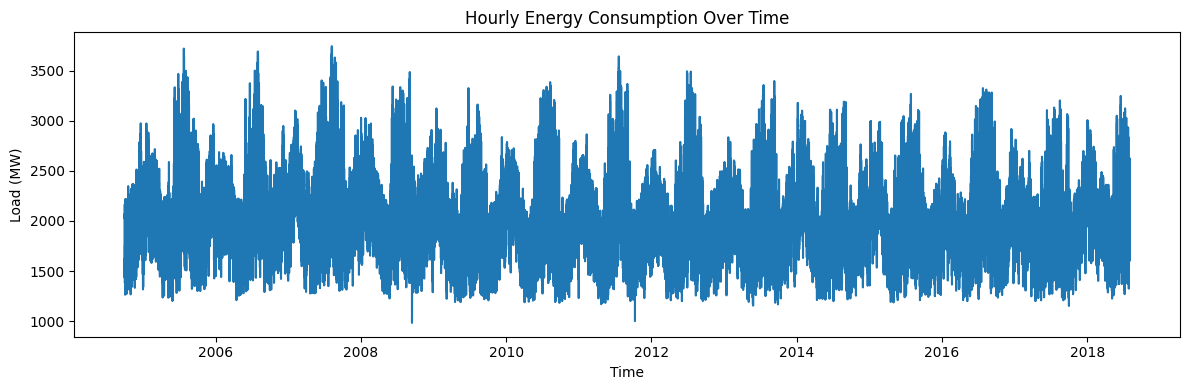

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df_e["datetime"], df_e["load"])
plt.title("Hourly Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.tight_layout()
plt.show()

In [ ]:
split_idx = int(len(df_e) * 0.8)

train = df_e.iloc[:split_idx]
test  = df_e.iloc[split_idx:]

print("Train size:", train.shape)
print("Test size:", test.shape)

Train size: (97020, 2)
Test size: (24255, 2)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

test = test.copy()
test["pred_naive"] = test["load"].shift(1)
test = test.dropna()

mae_naive = mean_absolute_error(test["load"], test["pred_naive"])
mse_naive = mean_squared_error(test["load"], test["pred_naive"])
rmse_naive = np.sqrt(mse_naive)

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)

Naive MAE: 62.501711128520185
Naive RMSE: 81.09006351087606


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# feature engineering
feat = df_e.copy()
feat["hour"] = feat["datetime"].dt.hour
feat["dayofweek"] = feat["datetime"].dt.dayofweek
feat["month"] = feat["datetime"].dt.month
feat["lag_1"] = feat["load"].shift(1)
feat["lag_24"] = feat["load"].shift(24)
feat["rolling_24_mean"] = feat["load"].shift(1).rolling(24).mean()
feat = feat.dropna().reset_index(drop=True)

# Daha hızlı olsun diye örnekleme
feat_small = feat.iloc[-50000:].copy()   # son 50k gözlem

split_idx = int(len(feat_small) * 0.8)
train_f = feat_small.iloc[:split_idx]
test_f  = feat_small.iloc[split_idx:]

X_train = train_f[["hour","dayofweek","month","lag_1","lag_24","rolling_24_mean"]]
y_train = train_f["load"]

X_test  = test_f[["hour","dayofweek","month","lag_1","lag_24","rolling_24_mean"]]
y_test  = test_f["load"]

rf = RandomForestRegressor(
    n_estimators=120,        # 300 -> 120 (hız)
    max_depth=18,           # hız + overfit kontrolü
    min_samples_leaf=2,     # hız + genelleme
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 22.72902089398581
Random Forest RMSE: 33.312840602817765


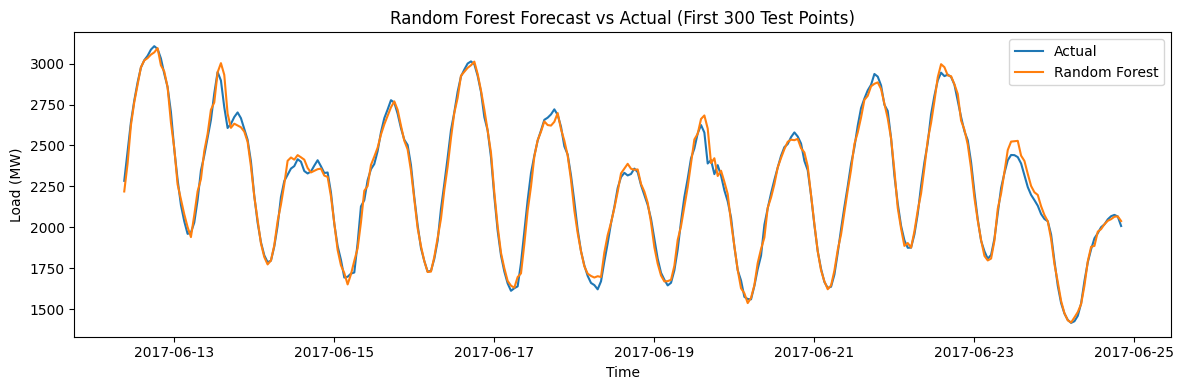

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(test_f["datetime"].iloc[:300], y_test.iloc[:300], label="Actual")
plt.plot(test_f["datetime"].iloc[:300], pred_rf[:300], label="Random Forest")
plt.title("Random Forest Forecast vs Actual (First 300 Test Points)")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

results_energy = pd.DataFrame({
    "Model": ["Naive Forecast", "Random Forest"],
    "MAE": [mae_naive, mae_rf],
    "RMSE": [rmse_naive, rmse_rf]
})

results_energy

,Model,MAE,RMSE
0,Naive Forecast,62.501711,81.090064
1,Random Forest,22.729021,33.312841


In [ ]:
import pandas as pd

df = pd.read_csv("DAYTON_hourly.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))


Shape: (121275, 2)
Columns: ['Datetime', 'DAYTON_MW']
              Datetime  DAYTON_MW
0  2004-12-31 01:00:00     1596.0
1  2004-12-31 02:00:00     1517.0
2  2004-12-31 03:00:00     1486.0


In [ ]:
import pandas as pd

# Datetime -> datetime type
df["Datetime"] = pd.to_datetime(df["Datetime"])

# Set index (time series format)
df = df.set_index("Datetime")

# Rename target column to a standard name
df = df.rename(columns={"DAYTON_MW": "load"})

# Sort by time just in case
df = df.sort_index()

print(df.head(3))
print(df.index.min(), "->", df.index.max())


                       load
Datetime                   
2004-10-01 01:00:00  1621.0
2004-10-01 02:00:00  1536.0
2004-10-01 03:00:00  1500.0
2004-10-01 01:00:00 -> 2018-08-03 00:00:00


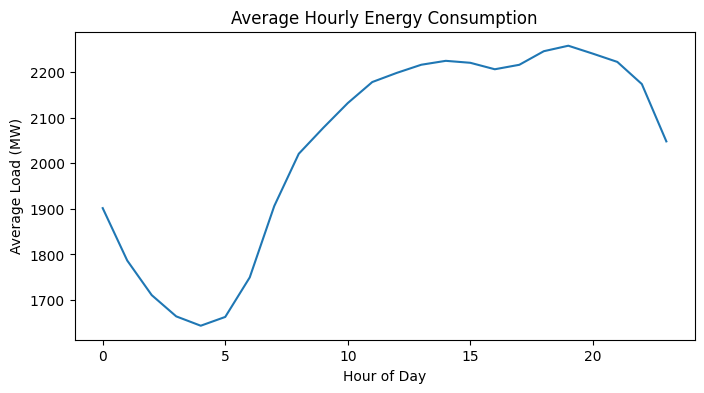

In [ ]:
import matplotlib.pyplot as plt

df["hour"] = df.index.hour
daily_avg = df.groupby("hour")["load"].mean()

plt.figure(figsize=(8,4))
plt.plot(daily_avg)
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (MW)")
plt.title("Average Hourly Energy Consumption")
plt.show()
